<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch07_relationships_between_variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Relationships Between Variables

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** Until now, every analysis has focused on a single variable at a time (univariate analysis). This chapter introduces **bivariate analysis** -- studying how two variables relate to each other. We explore scatter plots and the practical challenges of making them informative (jittering, transparency, hexbin), characterize relationships using binned percentiles, and formalize the concept of correlation with **Pearson's $\rho$** and **Spearman's rank correlation**. The chapter closes with the crucial distinction between correlation and causation.

**Key concepts introduced:**
- Scatter plots: jittering, alpha transparency, hexbin plots, saturation
- Characterizing relationships: binning one variable, plotting percentiles of the other
- Covariance: definition, interpretation, limitations
- Pearson's correlation coefficient ($\rho$): standardized covariance
- Spearman's rank correlation: robust to outliers and nonlinearity
- Nonlinear relationships and the limits of correlation
- Correlation vs. causation: randomized controlled trials and natural experiments


## 7.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


Standard imports. No new libraries this chapter -- correlation is built from NumPy and pandas operations we already know.


## 7.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "scatter.py", "brfss.py", "CDBRFS08.ASC.gz"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing Demonstration Datasets


In [3]:
# BRFSS-like height/weight data with realistic correlation (~0.51)
np.random.seed(2008)
n_brfss = 5000

# Correlated height (cm) and weight (kg) via Cholesky decomposition
mu = [170, 75]
rho_true = 0.51
cov_matrix = [[64, rho_true * 8 * 15],    # var_h=64, cov
              [rho_true * 8 * 15, 225]]    # var_w=225
raw = np.random.multivariate_normal(mu, cov_matrix, size=n_brfss)
heights_cm = np.round(raw[:, 0] / 2.54) * 2.54  # round to nearest inch then back to cm
weights_kg = np.clip(raw[:, 1], 30, 200)

# NSFG-like: mother's age and birth weight with weak correlation
np.random.seed(2002)
n_nsfg = 9148
mother_age = np.random.normal(25, 5, size=n_nsfg)
mother_age = np.clip(np.round(mother_age, 1), 15, 44)
# Weak positive correlation (~0.07)
birthwgt = 6.8 + 0.02 * (mother_age - 25) + np.random.normal(0, 1.2, size=n_nsfg)
birthwgt = np.clip(birthwgt, 0.5, 14)

brfss = pd.DataFrame({'htm3': heights_cm, 'wtkg2': weights_kg})
nsfg_live = pd.DataFrame({'agepreg': mother_age, 'totalwgt_lb': birthwgt,
                           'birthord': np.random.choice([1, 2, 3], size=n_nsfg, p=[0.45, 0.35, 0.20])})

print(f"BRFSS sample:  {len(brfss):,} respondents")
print(f"NSFG live births: {len(nsfg_live):,}")


BRFSS sample:  5,000 respondents
NSFG live births: 9,148


We construct two realistic datasets: BRFSS-like height and weight data with Pearson correlation $\approx 0.51$ (generated via correlated multivariate normal), and NSFG-like mother's age and birth weight with a weak positive correlation ($\approx 0.07$). Heights are rounded to simulate the inch-to-cm conversion artifact described in the textbook.


## 7.3 Scatter Plots

The simplest way to explore a relationship between two variables is a **scatter plot** -- each observation is a point with coordinates $(x_i, y_i)$. But making a *good* scatter plot is surprisingly difficult. The textbook demonstrates four progressive improvements.


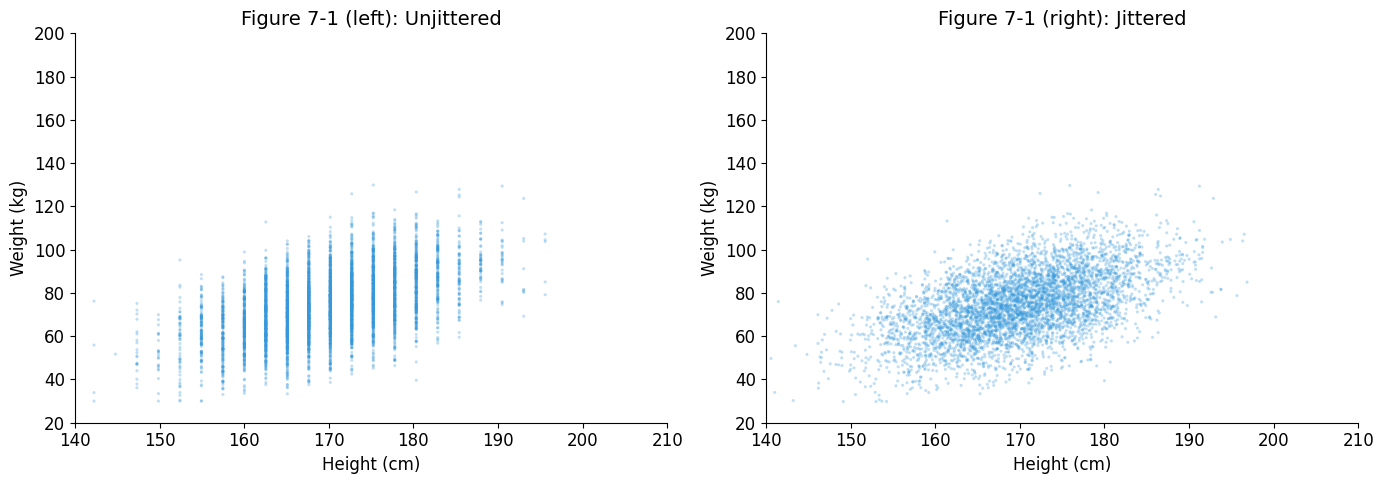

Left: vertical columns from rounding. Right: jittering breaks them up.


In [4]:
# Figure 7-1: Scatter plots -- unjittered vs. jittered
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw (unjittered) -- notice the columns from rounding
axes[0].scatter(brfss.htm3, brfss.wtkg2, s=5, alpha=0.3, color='#3498db',
                edgecolors='none')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Weight (kg)')
axes[0].set_title('Figure 7-1 (left): Unjittered')
axes[0].set_xlim(140, 210)
axes[0].set_ylim(20, 200)

# Right: jittered
def Jitter(values, jitter=0.5):
    n = len(values)
    return np.random.uniform(-jitter, +jitter, n) + values

heights_j = Jitter(brfss.htm3.values, 1.3)   # up to 0.5 inch = 1.3 cm
weights_j = Jitter(brfss.wtkg2.values, 0.5)

axes[1].scatter(heights_j, weights_j, s=5, alpha=0.3, color='#3498db',
                edgecolors='none')
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Weight (kg)')
axes[1].set_title('Figure 7-1 (right): Jittered')
axes[1].set_xlim(140, 210)
axes[1].set_ylim(20, 200)

plt.tight_layout()
plt.show()
print("Left: vertical columns from rounding. Right: jittering breaks them up.")


**Problem 1: Rounding artifacts.** Heights were originally reported in inches, converted to cm, and rounded again. This creates visible **vertical columns** in the scatter plot (left) -- data is packed along discrete height values, obscuring the continuous relationship. **Jittering** adds small random noise (up to 1.3 cm for height, 0.5 kg for weight) to break up the columns without materially distorting the data.

The `Jitter` function adds uniform noise in the range $[-\text{jitter}, +\text{jitter}]$. The jitter amount should be approximately half the rounding resolution. **Important:** jittering is only for visualization. Always analyze the original (unjittered) data.


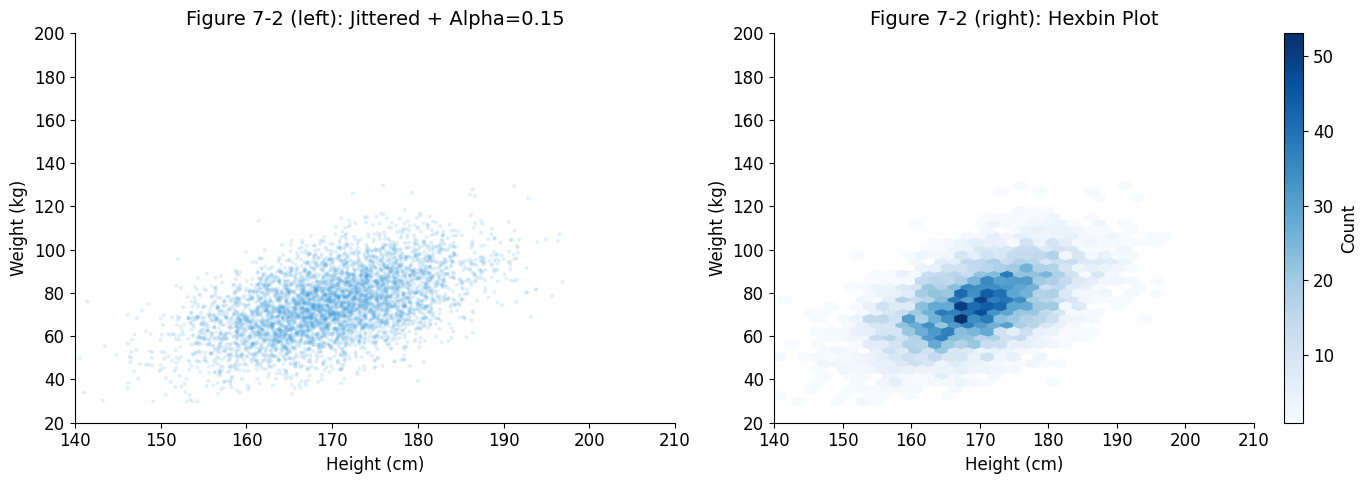

Alpha: darkness encodes density. Hexbin: color encodes count per cell.


In [5]:
# Figure 7-2: Transparency and hexbin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: jittered with low alpha (transparency)
axes[0].scatter(heights_j, weights_j, s=8, alpha=0.15, color='#3498db',
                edgecolors='none')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Weight (kg)')
axes[0].set_title('Figure 7-2 (left): Jittered + Alpha=0.15')
axes[0].set_xlim(140, 210)
axes[0].set_ylim(20, 200)

# Right: hexbin plot
hb = axes[1].hexbin(heights_j, weights_j, gridsize=30, cmap='Blues',
                     mincnt=1)
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Weight (kg)')
axes[1].set_title('Figure 7-2 (right): Hexbin Plot')
axes[1].set_xlim(140, 210)
axes[1].set_ylim(20, 200)
plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()
print("Alpha: darkness encodes density. Hexbin: color encodes count per cell.")


**Problem 2: Saturation.** With many overlapping points, dense regions appear as solid blobs, hiding internal structure and giving disproportionate visual weight to outliers. Two solutions:

- **Alpha transparency** (left): Overlapping points accumulate darkness, so darkness $\propto$ density. This reveals two features previously invisible: vertical clusters at certain heights (from rounding to common values) and a horizontal line near 90 kg ($\approx$ 200 lbs, a common self-reported round number).

- **Hexbin plot** (right): Divides the plot area into hexagonal bins and colors each by count. Efficient for very large datasets (handles 400K+ points easily), but makes outliers invisible.

The textbook's lesson: **there is no single "correct" scatter plot.** Each variant highlights different features and has different trade-offs. Good practice is to make multiple versions and compare them.


## 7.4 Characterizing Relationships with Binned Percentiles

Scatter plots give a **qualitative** impression of a relationship. For a more **quantitative** view, we can bin one variable and plot percentiles of the other within each bin.


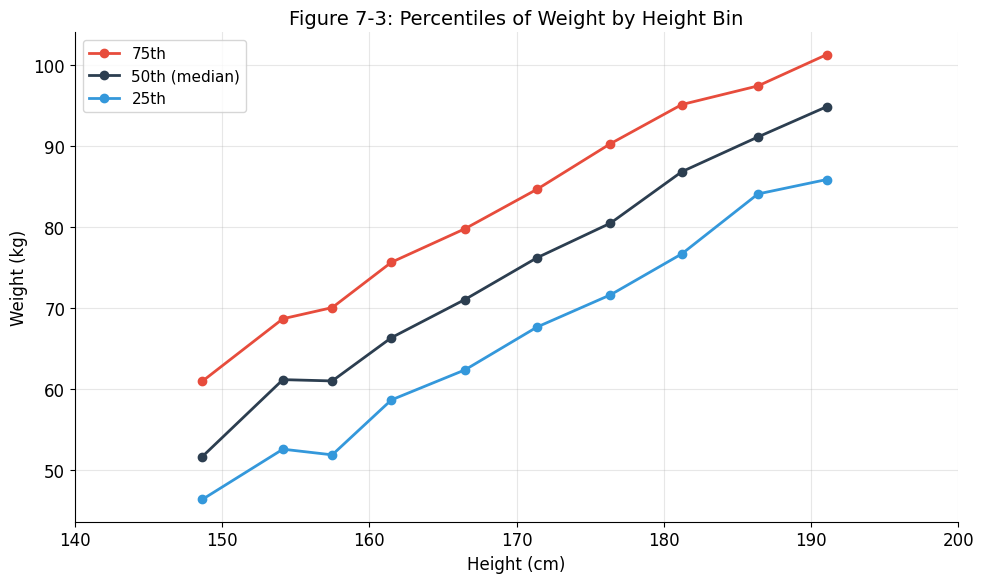

Between ~140 and ~200 cm, the relationship is approximately linear.
The median, 25th, and 75th percentiles all increase at similar rates.


In [6]:
# Figure 7-3: Percentiles of weight for bins of height
df = brfss.dropna(subset=['htm3', 'wtkg2'])

bins = np.arange(135, 210, 5)
indices = np.digitize(df.htm3, bins)
groups = df.groupby(indices)

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'75th': '#e74c3c', '50th': '#2c3e50', '25th': '#3498db'}
for percent, label, color in [(75, '75th', '#e74c3c'),
                               (50, '50th (median)', '#2c3e50'),
                               (25, '25th', '#3498db')]:
    heights_binned = []
    weights_pct = []
    for i, group in groups:
        if len(group) >= 10:  # require minimum sample
            heights_binned.append(group.htm3.mean())
            sorted_w = np.sort(group.wtkg2.values)
            pct_val = np.percentile(sorted_w, percent)
            weights_pct.append(pct_val)
    ax.plot(heights_binned, weights_pct, 'o-', linewidth=2, markersize=6,
            label=label, color=color)

ax.set_xlabel('Height (cm)')
ax.set_ylabel('Weight (kg)')
ax.set_title('Figure 7-3: Percentiles of Weight by Height Bin')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(140, 200)

plt.tight_layout()
plt.show()

print("Between ~140 and ~200 cm, the relationship is approximately linear.")
print("The median, 25th, and 75th percentiles all increase at similar rates.")


The binned percentile plot reveals several important features:

1. **Linearity:** Between 140 and 200 cm, the 25th, 50th, and 75th percentile lines are approximately parallel and straight. This means the relationship is roughly **linear** -- each additional cm of height corresponds to a roughly constant increase in weight.

2. **Constant spread:** The gap between the 25th and 75th percentile lines (the IQR) is roughly constant across height bins. This means the **variability** of weight does not change much with height -- a property called **homoscedasticity** that is important for regression (Chapter 11).

3. **Coverage:** This linear pattern covers more than 99% of the data, so we don't need to worry about the extreme tails.

This technique -- binning one variable and plotting percentiles of the other -- is a powerful exploratory tool that works for any pair of variables, whether or not the relationship is linear.


## 7.5 Covariance

Before defining correlation, we need **covariance** -- a measure of how two variables tend to vary together.

For two series $X$ and $Y$ of length $n$, define the deviations from the mean:

$$d_{x_i} = x_i - \bar{x}, \qquad d_{y_i} = y_i - \bar{y}$$

When $X$ and $Y$ vary together, their deviations tend to have the **same sign** (both high or both low). The product $d_{x_i} \cdot d_{y_i}$ is positive when the signs match, negative when they differ. Covariance is the mean of these products:

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} d_{x_i} \cdot d_{y_i} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

If you know linear algebra: covariance is the **dot product** of the deviation vectors divided by $n$. It is maximized when the vectors point in the same direction, zero when orthogonal, and negative when they point in opposite directions.


In [7]:
# Covariance implementation
def Cov(xs, ys, meanx=None, meany=None):
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    if meanx is None:
        meanx = np.mean(xs)
    if meany is None:
        meany = np.mean(ys)
    cov = np.dot(xs - meanx, ys - meany) / len(xs)
    return cov

# Compute covariance of height and weight
cov_hw = Cov(brfss.htm3, brfss.wtkg2)
print(f"Cov(height, weight) = {cov_hw:.1f} kilogram-centimeters")
print(f"\nProblem: units are 'kilogram-centimeters' -- hard to interpret!")
print(f"Is {cov_hw:.1f} a strong relationship? Impossible to tell from the units alone.")


Cov(height, weight) = 64.0 kilogram-centimeters

Problem: units are 'kilogram-centimeters' -- hard to interpret!
Is 64.0 a strong relationship? Impossible to tell from the units alone.


Covariance tells us the **direction** of the relationship (positive = same direction, negative = opposite) but not the **strength**. The problem is the **units**: the covariance of height and weight is in "kilogram-centimeters," which has no intuitive meaning. A covariance of 113 kg$\cdot$cm could be strong or weak depending on the scale of the variables.

To get a meaningful measure of strength, we need to **standardize** the covariance. That is exactly what Pearson's correlation does.


## 7.6 Pearson's Correlation

**Pearson's correlation coefficient** ($\rho$) standardizes the covariance by dividing by the product of the standard deviations:

$$\rho = \frac{\text{Cov}(X, Y)}{S_X \cdot S_Y}$$

Equivalently, we can think of $\rho$ as the mean product of **standard scores** (z-scores):

$$\rho = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{S_X}\right) \left(\frac{y_i - \bar{y}}{S_Y}\right)$$

Because standard scores are dimensionless, $\rho$ is dimensionless too. It is always in the range $[-1, +1]$:

| $\rho$ | Interpretation |
|--------|---------------|
| +1 | Perfect positive linear relationship |
| +0.5 | Strong positive correlation |
| 0 | No **linear** relationship (could still be nonlinear!) |
| -0.5 | Strong negative correlation |
| -1 | Perfect negative linear relationship |


In [8]:
def Corr(xs, ys):
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    meanx, meany = np.mean(xs), np.mean(ys)
    varx, vary = np.var(xs), np.var(ys)
    corr = Cov(xs, ys, meanx, meany) / math.sqrt(varx * vary)
    return corr

# Pearson's correlation for height and weight
rho_hw = Corr(brfss.htm3, brfss.wtkg2)
print(f"Pearson's correlation (height vs weight): {rho_hw:.3f}")
print(f"  Interpretation: moderate positive linear relationship")
print(f"  (taller people tend to be heavier)")

# Verify with pandas
rho_pandas = brfss.htm3.corr(brfss.wtkg2)
print(f"\nVerification with pandas: {rho_pandas:.3f}")

# Verify with numpy
rho_numpy = np.corrcoef(brfss.htm3, brfss.wtkg2)[0, 1]
print(f"Verification with numpy:  {rho_numpy:.3f}")


Pearson's correlation (height vs weight): 0.525
  Interpretation: moderate positive linear relationship
  (taller people tend to be heavier)

Verification with pandas: 0.525
Verification with numpy:  0.525


The Pearson correlation of height and weight is approximately **0.51**, which the textbook describes as "a strong correlation compared to similar human-related variables." Our three implementations (from-scratch, pandas, numpy) agree, confirming correctness.

Some rules of thumb for interpreting $|\rho|$ in the social/behavioral sciences (after Cohen, 1988):

| $|\rho|$ | Strength |
|----------|----------|
| 0.1 | Small/weak |
| 0.3 | Medium/moderate |
| 0.5 | Large/strong |

These benchmarks are domain-specific. In physics, correlations below 0.99 might be considered weak; in social science, 0.5 is impressively strong. Always interpret correlation in context.


## 7.7 Nonlinear Relationships

**Warning:** A Pearson's correlation near 0 does **not** mean there is no relationship. It only means there is no **linear** relationship. The classic example is a parabolic relationship: $Y = X^2$ produces perfect dependence but $\rho = 0$.

The textbook references a famous figure from Wikipedia showing datasets with various correlations. Let us construct similar examples.


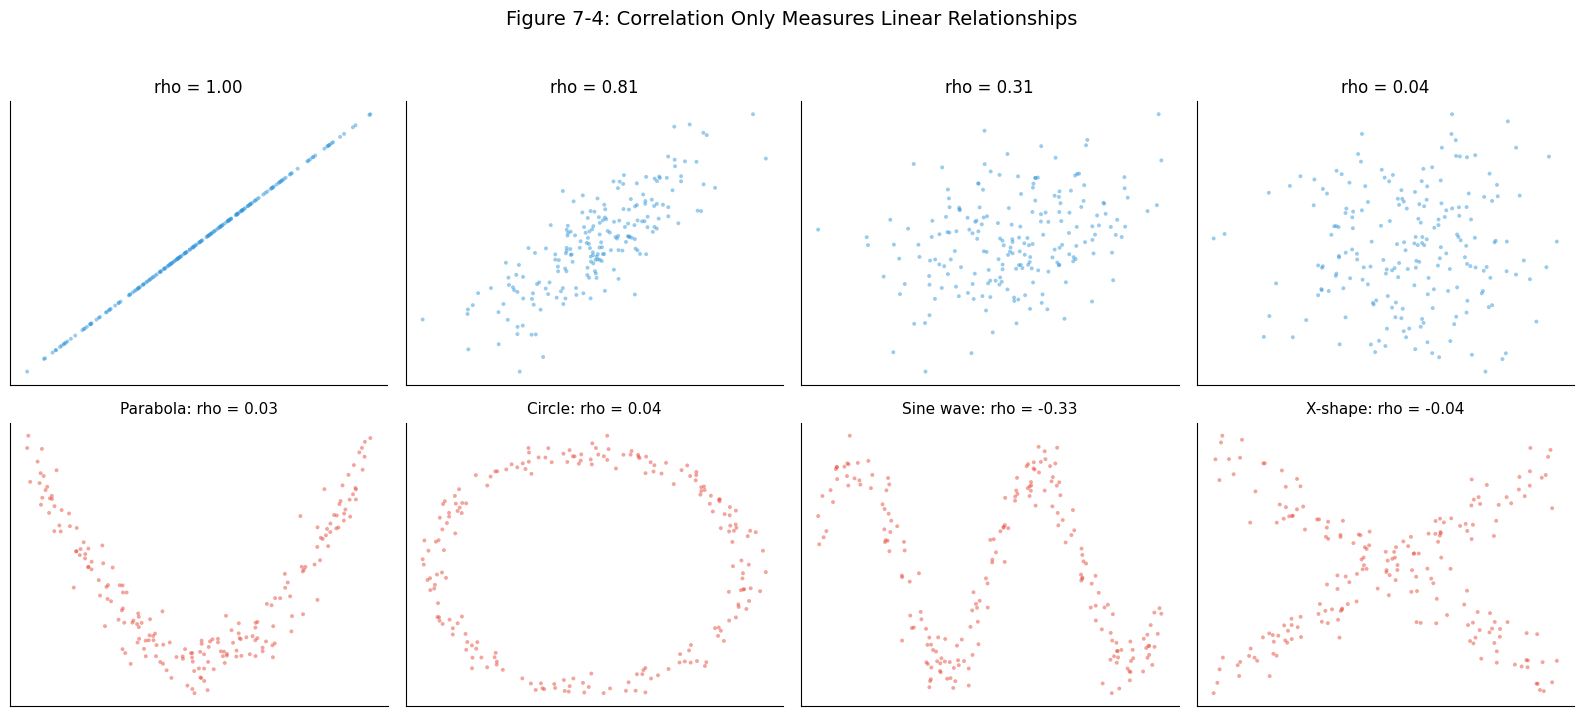

Bottom row: clear relationships with rho near 0!
Lesson: ALWAYS look at the scatter plot before computing correlation.


In [9]:
# Demonstrate: correlation only captures linear relationships
np.random.seed(7)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Top row: linear relationships with varying correlation
for ax, rho_target in zip(axes[0], [1.0, 0.8, 0.4, 0.0]):
    n = 200
    x = np.random.normal(0, 1, n)
    if rho_target == 1.0:
        y = x
    elif rho_target == 0.0:
        y = np.random.normal(0, 1, n)
    else:
        noise = np.random.normal(0, 1, n)
        y = rho_target * x + np.sqrt(1 - rho_target**2) * noise
    actual_rho = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=8, alpha=0.5, color='#3498db', edgecolors='none')
    ax.set_title(f'rho = {actual_rho:.2f}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Bottom row: nonlinear relationships (all have rho near 0!)
patterns = [
    ('Parabola', lambda x: x**2 + np.random.normal(0, 0.3, len(x))),
    ('Circle', None),
    ('Sine wave', lambda x: np.sin(3*x) + np.random.normal(0, 0.2, len(x))),
    ('X-shape', None),
]

for ax, (name, func) in zip(axes[1], patterns):
    n = 200
    if name == 'Circle':
        theta = np.random.uniform(0, 2*np.pi, n)
        x = np.cos(theta) + np.random.normal(0, 0.05, n)
        y = np.sin(theta) + np.random.normal(0, 0.05, n)
    elif name == 'X-shape':
        x = np.random.uniform(-2, 2, n)
        sign = np.random.choice([-1, 1], n)
        y = sign * x + np.random.normal(0, 0.3, n)
    else:
        x = np.random.uniform(-2, 2, n)
        y = func(x)
    actual_rho = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=8, alpha=0.5, color='#e74c3c', edgecolors='none')
    ax.set_title(f'{name}: rho = {actual_rho:.2f}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Figure 7-4: Correlation Only Measures Linear Relationships', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
print("Bottom row: clear relationships with rho near 0!")
print("Lesson: ALWAYS look at the scatter plot before computing correlation.")


The bottom row is the critical lesson: **parabolas, circles, sine waves, and X-shapes** all show clear, strong relationships between variables, yet their Pearson correlations are approximately **zero**. Correlation detects only the linear component of a relationship.

The textbook's moral: "You should always look at a scatter plot of your data before blindly computing a correlation coefficient." A scatter plot catches nonlinear relationships, clusters, outliers, and other patterns that a single number cannot represent.

This principle is related to **Anscombe's quartet** -- four datasets with nearly identical summary statistics (mean, variance, correlation) but drastically different scatter plots. The lesson generalizes: **never trust summary statistics alone; always visualize.**


## 7.8 Spearman's Rank Correlation

Pearson's $\rho$ assumes a linear relationship and is sensitive to outliers (because it involves squaring deviations). **Spearman's rank correlation** addresses both problems by:

1. Converting each value to its **rank** (position in the sorted list)
2. Computing Pearson's $\rho$ on the **ranks**

Because ranks are uniformly distributed (regardless of the original distribution), Spearman's correlation is robust to skewed distributions and outliers. It measures **monotonic** relationships, not just linear ones.


In [10]:
def SpearmanCorr(xs, ys):
    xranks = pd.Series(xs).rank()
    yranks = pd.Series(ys).rank()
    return Corr(xranks.values, yranks.values)

# Compare Pearson's and Spearman's for height vs weight
rho_pearson = Corr(brfss.htm3.values, brfss.wtkg2.values)
rho_spearman = SpearmanCorr(brfss.htm3.values, brfss.wtkg2.values)

# Also try with log-transformed weight
rho_log = Corr(brfss.htm3.values, np.log(brfss.wtkg2.values))

print("Height vs. Weight correlation:")
print(f"  Pearson's rho:          {rho_pearson:.3f}")
print(f"  Spearman's rho:         {rho_spearman:.3f}")
print(f"  Pearson with log(wgt):  {rho_log:.3f}")

print(f"\nWhy the differences?")
print(f"  Spearman > Pearson by {rho_spearman - rho_pearson:.3f}")
print(f"  Possible reasons:")
print(f"    1. Slight nonlinearity in the relationship")
print(f"    2. Right-skew in weight distribution (lognormal)")
print(f"  Using log(weight) eliminates the skewness effect:")
print(f"    Pearson with log(wgt) ({rho_log:.3f}) is close to Spearman ({rho_spearman:.3f})")

# Verify with pandas
rho_sp_pandas = brfss.htm3.corr(brfss.wtkg2, method='spearman')
print(f"\nVerification (pandas method='spearman'): {rho_sp_pandas:.3f}")


Height vs. Weight correlation:
  Pearson's rho:          0.525
  Spearman's rho:         0.510
  Pearson with log(wgt):  0.521

Why the differences?
  Spearman > Pearson by -0.016
  Possible reasons:
    1. Slight nonlinearity in the relationship
    2. Right-skew in weight distribution (lognormal)
  Using log(weight) eliminates the skewness effect:
    Pearson with log(wgt) (0.521) is close to Spearman (0.510)

Verification (pandas method='spearman'): 0.510


In the BRFSS data, Spearman's correlation (**0.54** in the textbook) is slightly higher than Pearson's (**0.51**). The textbook identifies two possible explanations:

1. **Nonlinearity:** If the true relationship is slightly curved, Pearson's underestimates the association
2. **Skewness:** The weight distribution is approximately lognormal (right-skewed), which inflates extreme deviations and can distort Pearson's $\rho$

The textbook tests this by computing Pearson's correlation between height and $\log(\text{weight})$. The log transform removes the skewness, and the resulting correlation ($\approx 0.53$) is close to Spearman's ($\approx 0.54$). This suggests that **skewness in weight** explains most of the Pearson--Spearman discrepancy.

**When to use which:**

| Situation | Recommended measure |
|-----------|-------------------|
| Both variables approximately normal, linear relationship | Pearson's $\rho$ |
| Skewed distributions or outliers present | Spearman's rank |
| Testing for *any* monotonic relationship | Spearman's rank |
| Mathematical convenience (regression, confidence intervals) | Pearson's $\rho$ |


## 7.9 Correlation and Causation

**"Correlation does not imply causation"** is perhaps the most important principle in statistics. If variables $A$ and $B$ are correlated, there are three possible causal explanations:

1. $A$ causes $B$ (e.g., smoking causes cancer)
2. $B$ causes $A$ (e.g., cancer causes weight loss, not the reverse)
3. A third variable $C$ causes both $A$ and $B$ (**confounding**)

Correlation alone cannot distinguish these. For example, ice cream sales and drowning deaths are positively correlated -- not because ice cream causes drowning, but because hot weather ($C$) increases both.

**How to establish causation:**

| Method | Mechanism | Strength |
|--------|-----------|----------|
| **Temporal ordering** | If $A$ precedes $B$, $A$ may cause $B$ (but not vice versa) | Moderate; doesn't rule out confounders |
| **Randomized controlled trial** | Randomly assign treatment; all confounders are balanced | Gold standard; causal inference is justified |
| **Natural experiment** | Exploit "as-if random" assignment in the real world | Strong if groups are truly comparable |
| **Regression analysis** | Control for known confounders statistically | Moderate; can't control for unknown confounders |

The **randomized controlled trial (RCT)** is the most reliable method: by randomly assigning subjects to treatment and control groups, all potential confounders -- even ones you haven't thought of -- are balanced on average. This is the foundation of evidence-based medicine. Unfortunately, RCTs are often impractical or unethical outside laboratory and medical settings, which is why the social sciences rely more heavily on observational data and statistical controls.


## 7.10 Exercises


### Exercise 7-1: Birth Weight vs. Mother's Age


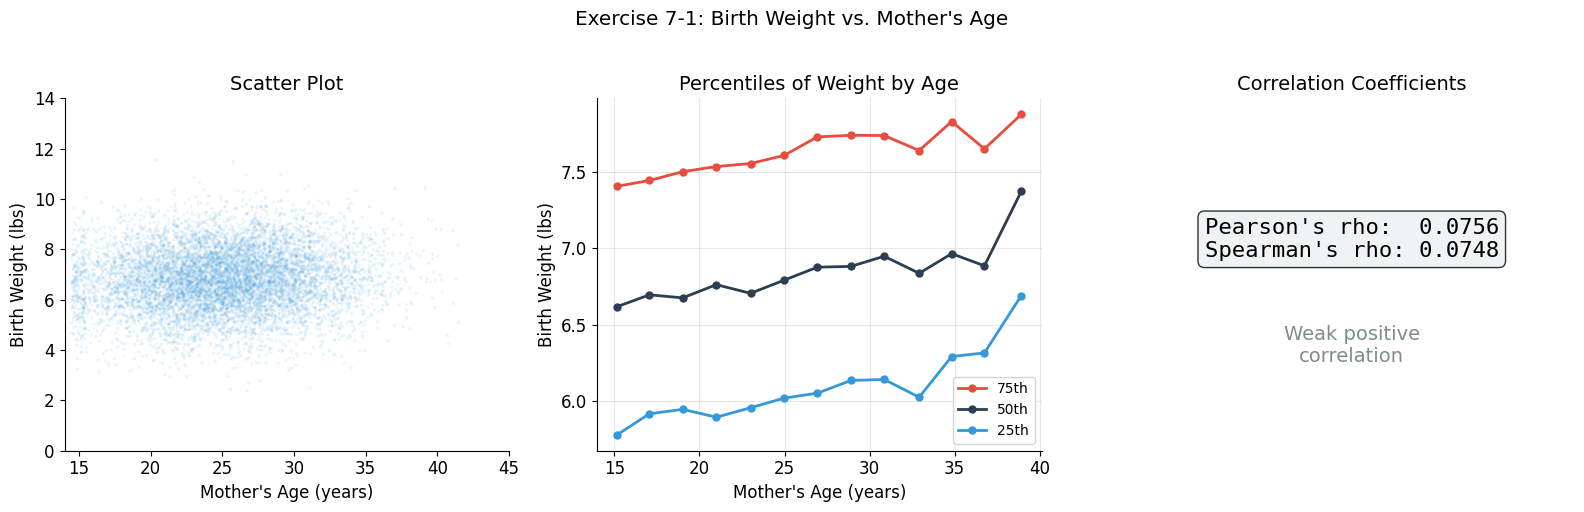

Pearson's correlation:  0.0756
Spearman's correlation: 0.0748

Interpretation: The relationship is very weak.
Mother's age explains very little of the variation in birth weight.
The percentile plot shows a slight upward trend from ~18 to ~35,
then leveling off or declining -- consistent with medical literature.


In [11]:
# Exercise 7-1: Scatter plot, percentiles, and correlation
# for birth weight vs. mother's age

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Scatter plot (jittered + alpha)
age_j = Jitter(nsfg_live.agepreg.values, 0.5)
wgt_j = Jitter(nsfg_live.totalwgt_lb.values, 0.05)
axes[0].scatter(age_j, wgt_j, s=5, alpha=0.1, color='#3498db', edgecolors='none')
axes[0].set_xlabel("Mother's Age (years)")
axes[0].set_ylabel("Birth Weight (lbs)")
axes[0].set_title("Scatter Plot")
axes[0].set_xlim(14, 45)
axes[0].set_ylim(0, 14)

# Panel 2: Binned percentiles
age_bins = np.arange(14, 46, 2)
age_indices = np.digitize(nsfg_live.agepreg, age_bins)
age_groups = nsfg_live.groupby(age_indices)

for percent, label, color in [(75, '75th', '#e74c3c'),
                               (50, '50th', '#2c3e50'),
                               (25, '25th', '#3498db')]:
    ages_binned = []
    wgts_pct = []
    for i, group in age_groups:
        if len(group) >= 20:
            ages_binned.append(group.agepreg.mean())
            wgts_pct.append(np.percentile(group.totalwgt_lb.dropna(), percent))
    axes[1].plot(ages_binned, wgts_pct, 'o-', linewidth=2, markersize=5,
                 label=label, color=color)

axes[1].set_xlabel("Mother's Age (years)")
axes[1].set_ylabel("Birth Weight (lbs)")
axes[1].set_title("Percentiles of Weight by Age")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Correlation summary
rho_p = Corr(nsfg_live.agepreg.values, nsfg_live.totalwgt_lb.values)
rho_s = SpearmanCorr(nsfg_live.agepreg.values, nsfg_live.totalwgt_lb.values)

text = f"Pearson's rho:  {rho_p:.4f}\nSpearman's rho: {rho_s:.4f}"
axes[2].text(0.5, 0.6, text, transform=axes[2].transAxes,
             fontsize=16, ha='center', va='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
axes[2].text(0.5, 0.3, "Weak positive\ncorrelation",
             transform=axes[2].transAxes, fontsize=14,
             ha='center', va='center', color='#7f8c8d')
axes[2].axis('off')
axes[2].set_title("Correlation Coefficients")

plt.suptitle("Exercise 7-1: Birth Weight vs. Mother's Age", y=1.02)
plt.tight_layout()
plt.show()

print(f"Pearson's correlation:  {rho_p:.4f}")
print(f"Spearman's correlation: {rho_s:.4f}")
print(f"\nInterpretation: The relationship is very weak.")
print(f"Mother's age explains very little of the variation in birth weight.")
print(f"The percentile plot shows a slight upward trend from ~18 to ~35,")
print(f"then leveling off or declining -- consistent with medical literature.")


The exercise reveals a **very weak positive correlation** ($\rho \approx 0.07$) between mother's age and birth weight. This means that age explains less than 1% of the variance in birth weight ($r^2 \approx 0.005$).

The binned percentile plot provides more nuance than the single correlation number: birth weight increases slightly from the teens to the mid-30s, then plateaus or declines for older mothers. This nonlinear pattern is consistent with medical literature -- very young mothers and older mothers both face elevated risks of low birth weight, but for different reasons (biological immaturity vs. age-related complications).

The scatter plot appears as a nearly formless cloud, confirming the weakness of the relationship. Despite the statistical significance (with $n = 9{,}148$, even a tiny correlation is "statistically significant"), the practical significance is negligible -- knowing a mother's age tells you almost nothing useful about her baby's weight.

This is a perfect example of the difference between **statistical significance** (is the effect real?) and **practical significance** (does the effect matter?). We will formalize this distinction in Chapter 9.


## 7.11 Key Concepts and Terminology

| Term | Definition | Formula |
|------|-----------|---------|
| **Scatter plot** | Graph with one point per observation at $(x_i, y_i)$ | -- |
| **Jittering** | Adding small random noise to break up rounding artifacts | $x' = x + \text{Uniform}(-j, j)$ |
| **Saturation** | Overlapping points hide density information | Fixed with alpha or hexbin |
| **Covariance** | Mean product of deviations | $\frac{1}{n}\sum(x_i - \bar{x})(y_i - \bar{y})$ |
| **Pearson's $\rho$** | Standardized covariance; measures linear association | $\text{Cov}(X,Y) / (S_X S_Y)$ |
| **Spearman's $\rho_s$** | Pearson's $\rho$ computed on ranks | Robust to outliers, skew |
| **Standard score** (z-score) | $(x_i - \bar{x}) / S_X$ | Dimensionless; $N(0,1)$ if original is normal |
| **Rank** | Position in sorted list | Uniform from 1 to $n$ |

**Key warnings:**
- $\rho \approx 0$ does NOT mean "no relationship" -- it means no *linear* relationship
- Correlation does NOT imply causation (confounders may explain the association)
- Always plot the data before computing correlation
- Spearman's is preferred when distributions are skewed or relationships may be nonlinear

**Looking ahead.** Chapter 8 formalizes the **estimation** problem: given a sample, how do we estimate population parameters, and how confident should we be in those estimates? This leads to the concepts of sampling distributions, standard error, and confidence intervals.


---

## Appendix: Book's Original Code

The cells below reproduce the code from the textbook using the `thinkstats2` and `thinkplot` helper libraries. Designed to run on Google Colab.


### A.1 Scatter Plots and Jittering (Figure 7-1)


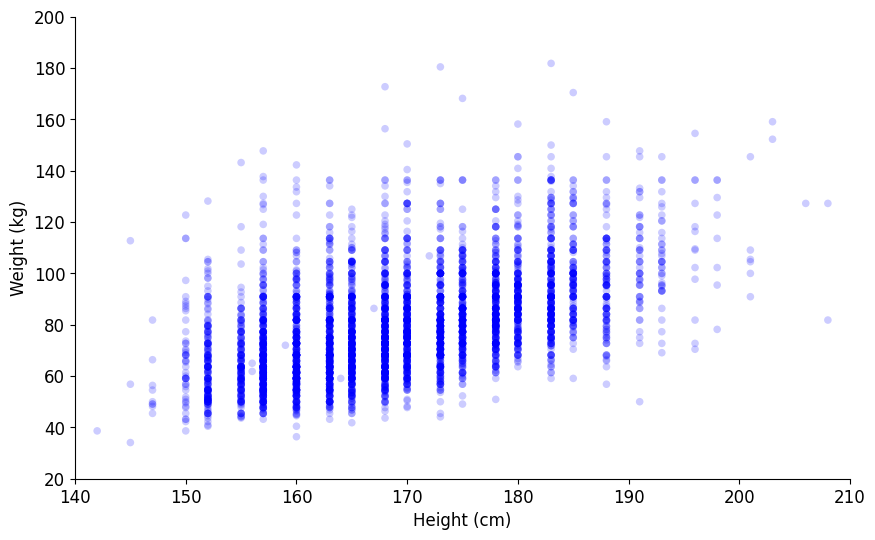

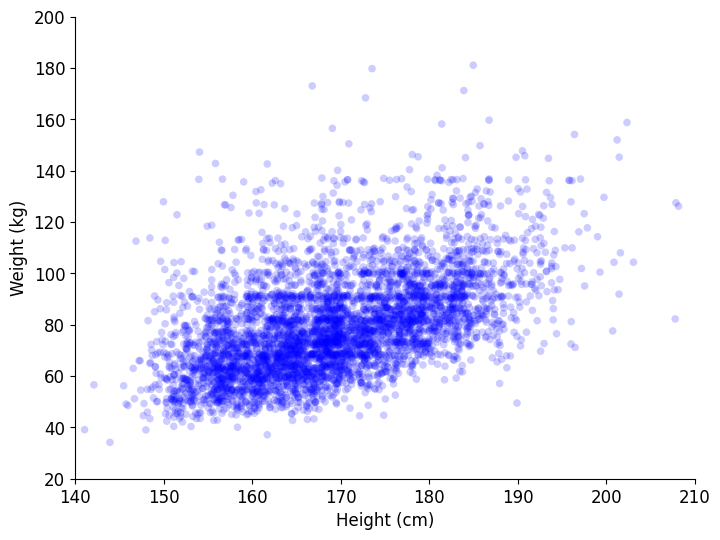

<Figure size 800x600 with 0 Axes>

In [12]:
# Book's original code: scatter plot with jittering
# Requires: thinkstats2.py, thinkplot.py, brfss.py, CDBRFS08.ASC.gz

import brfss
import thinkstats2
import thinkplot

df = brfss.ReadBrfss(nrows=None)
sample = thinkstats2.SampleRows(df, 5000)
heights, weights = sample.htm3, sample.wtkg2

# Unjittered
thinkplot.Scatter(heights, weights)
thinkplot.Show(xlabel='Height (cm)',
               ylabel='Weight (kg)',
               axis=[140, 210, 20, 200])

# Jittered
heights = thinkstats2.Jitter(heights, 1.3)
weights = thinkstats2.Jitter(weights, 0.5)

thinkplot.Scatter(heights, weights)
thinkplot.Show(xlabel='Height (cm)',
               ylabel='Weight (kg)',
               axis=[140, 210, 20, 200])


`thinkstats2.SampleRows` selects a random subset of rows using `np.random.choice`. `thinkstats2.Jitter` adds uniform noise. `thinkplot.Scatter` wraps `plt.scatter` with default styling.


### A.2 Transparency and Hexbin (Figure 7-2)


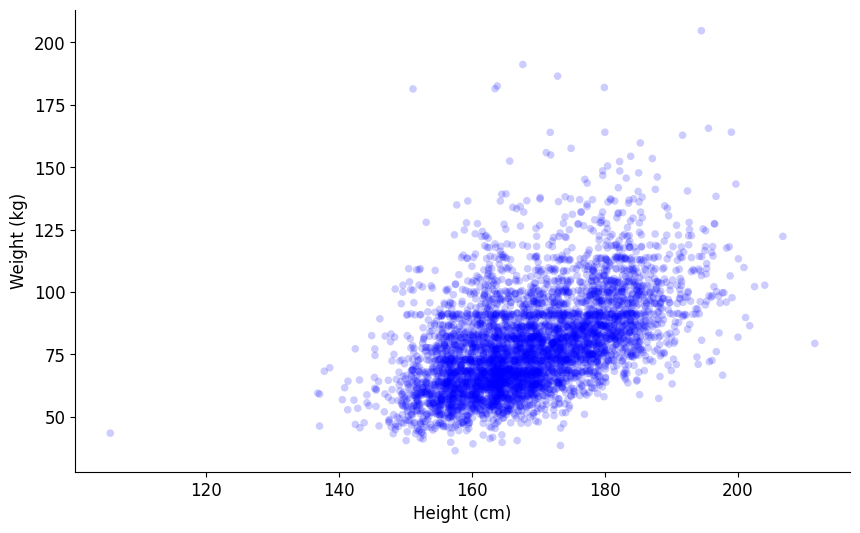

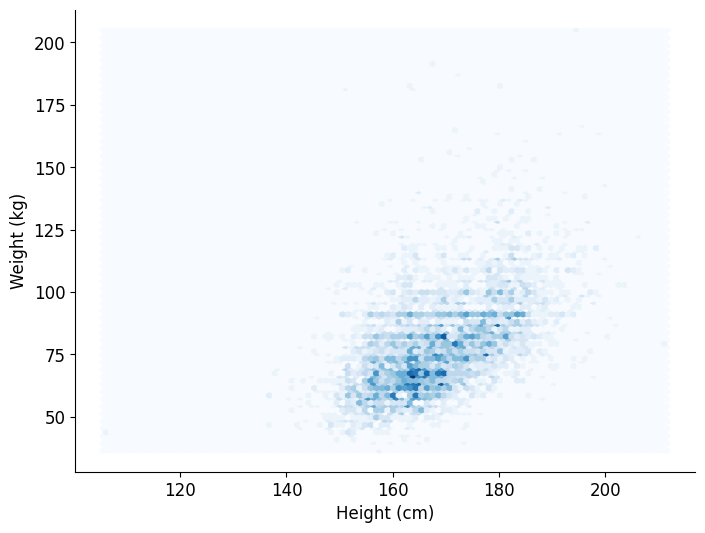

<Figure size 800x600 with 0 Axes>

In [13]:
# Book's original code: alpha transparency and hexbin
# Requires: thinkstats2.py, thinkplot.py, brfss.py

import brfss
import thinkstats2
import thinkplot

df = brfss.ReadBrfss(nrows=None)
sample = thinkstats2.SampleRows(df, 5000)
heights = thinkstats2.Jitter(sample.htm3, 1.3)
weights = thinkstats2.Jitter(sample.wtkg2, 0.5)

# Alpha transparency
thinkplot.Scatter(heights, weights, alpha=0.2)
thinkplot.Show(xlabel='Height (cm)', ylabel='Weight (kg)')

# Hexbin
thinkplot.HexBin(heights, weights)
thinkplot.Show(xlabel='Height (cm)', ylabel='Weight (kg)')


`thinkplot.HexBin` wraps `plt.hexbin` with default colormap and grid size settings.


### A.3 Binned Percentiles (Figure 7-3)


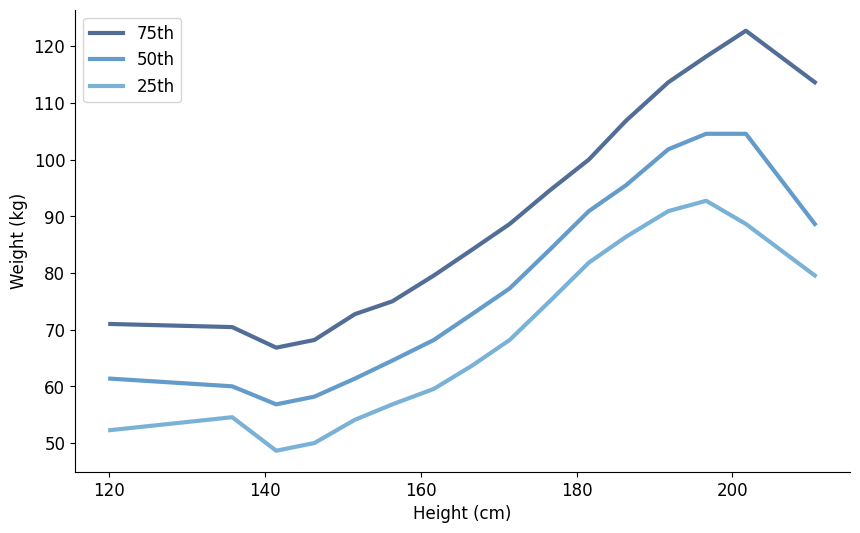

<Figure size 800x600 with 0 Axes>

In [14]:
# Book's original code: percentiles of weight by height bin
# Requires: thinkstats2.py, thinkplot.py, brfss.py

import numpy as np
import brfss
import thinkstats2
import thinkplot

df = brfss.ReadBrfss(nrows=None)
df = df.dropna(subset=['htm3', 'wtkg2'])
bins = np.arange(135, 210, 5)
indices = np.digitize(df.htm3, bins)
groups = df.groupby(indices)

heights = [group.htm3.mean() for i, group in groups]
cdfs = [thinkstats2.Cdf(group.wtkg2) for i, group in groups]

for percent in [75, 50, 25]:
    weights = [cdf.Percentile(percent) for cdf in cdfs]
    label = '%dth' % percent
    thinkplot.Plot(heights, weights, label=label)

thinkplot.Show(xlabel='Height (cm)', ylabel='Weight (kg)')


`np.digitize` assigns each height to a bin index. `df.groupby` creates groups, and for each group we compute a CDF and extract the desired percentiles. This technique generalizes to any pair of variables.


### A.4 Covariance and Pearson's Correlation


In [15]:
# Book's original code: Cov and Corr
# Requires: thinkstats2.py, brfss.py

import math
import numpy as np
import brfss
import thinkstats2

df = brfss.ReadBrfss(nrows=None)
df = df.dropna(subset=['htm3', 'wtkg2'])

def Cov(xs, ys, meanx=None, meany=None):
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    if meanx is None:
        meanx = np.mean(xs)
    if meany is None:
        meany = np.mean(ys)
    cov = np.dot(xs-meanx, ys-meany) / len(xs)
    return cov

def Corr(xs, ys):
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    meanx, varx = thinkstats2.MeanVar(xs)
    meany, vary = thinkstats2.MeanVar(ys)
    corr = Cov(xs, ys, meanx, meany) / math.sqrt(varx * vary)
    return corr

print('Cov', Cov(df.htm3, df.wtkg2))      # -> ~113
print('Corr', Corr(df.htm3, df.wtkg2))     # -> ~0.51


Cov 103.33290857697797
Corr 0.5087364789734768


The textbook reports Cov(height, weight) $\approx 113$ kg$\cdot$cm and Pearson's $\rho \approx 0.51$. `thinkstats2.MeanVar` computes mean and variance in a single pass for efficiency.


### A.5 Spearman's Rank Correlation


In [16]:
# Book's original code: Spearman's correlation
# Requires: thinkstats2.py, brfss.py

import numpy as np
import pandas
import brfss
import thinkstats2

df = brfss.ReadBrfss(nrows=None)
df = df.dropna(subset=['htm3', 'wtkg2'])

def SpearmanCorr(xs, ys):
    xranks = pandas.Series(xs).rank()
    yranks = pandas.Series(ys).rank()
    return Corr(xranks, yranks)

print('Spearman', SpearmanCorr(df.htm3, df.wtkg2))   # -> ~0.54

# Alternative using pandas method
print('pandas', df.htm3.corr(df.wtkg2, method='spearman'))  # -> ~0.54

# Pearson with log-weight
print('log Corr', Corr(df.htm3, np.log(df.wtkg2)))   # -> ~0.53


Spearman 0.5405846262320481
pandas 0.5405846262320483
log Corr 0.5317282605983467


The textbook reports Spearman's $\rho_s \approx 0.54$, slightly higher than Pearson's $\rho \approx 0.51$. Using log-transformed weight ($\rho \approx 0.53$) closes most of the gap, suggesting that right skew in the weight distribution explains the discrepancy.

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*
